In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import catboost as catb
from sklearn import linear_model
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
data = pd.read_csv('stud.csv')
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
data['Total_Score'] = data['math_score']+ data['writing_score'] + data['reading_score']
data['avg'] = data['Total_Score']/3

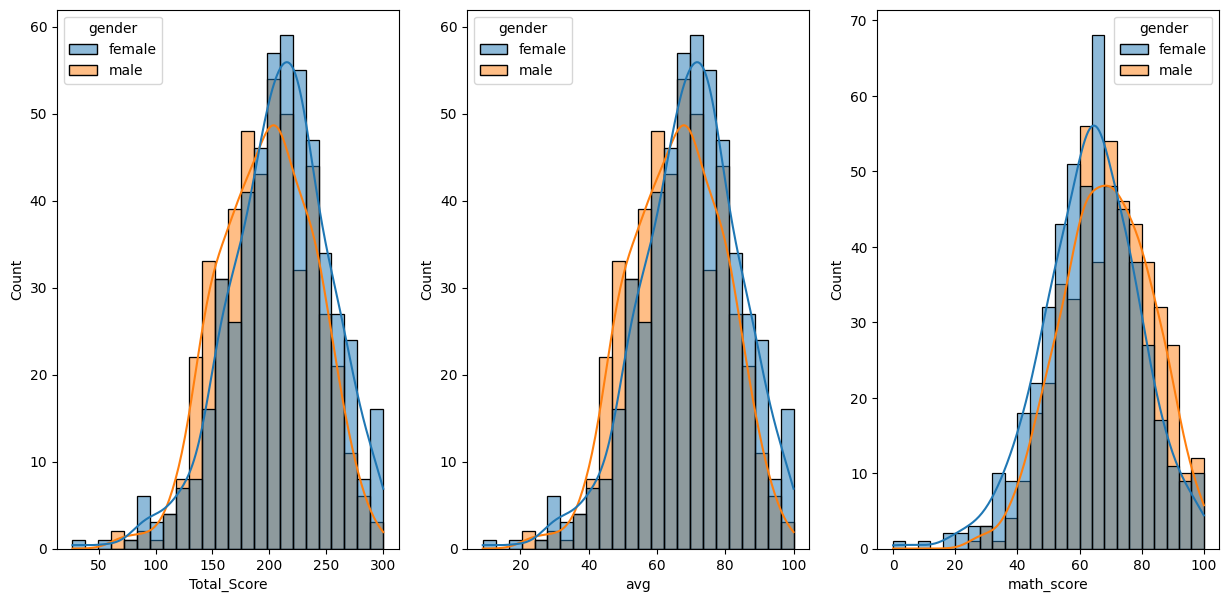

In [4]:
import seaborn as sns
fig,axs = plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(data=data,x='Total_Score',kde=True,hue='gender')
plt.subplot(132)
sns.histplot(data=data,x='avg',kde = True, hue = 'gender')
plt.subplot(133)
sns.histplot(data=data,x='math_score',kde=True,hue='gender')
plt.show()

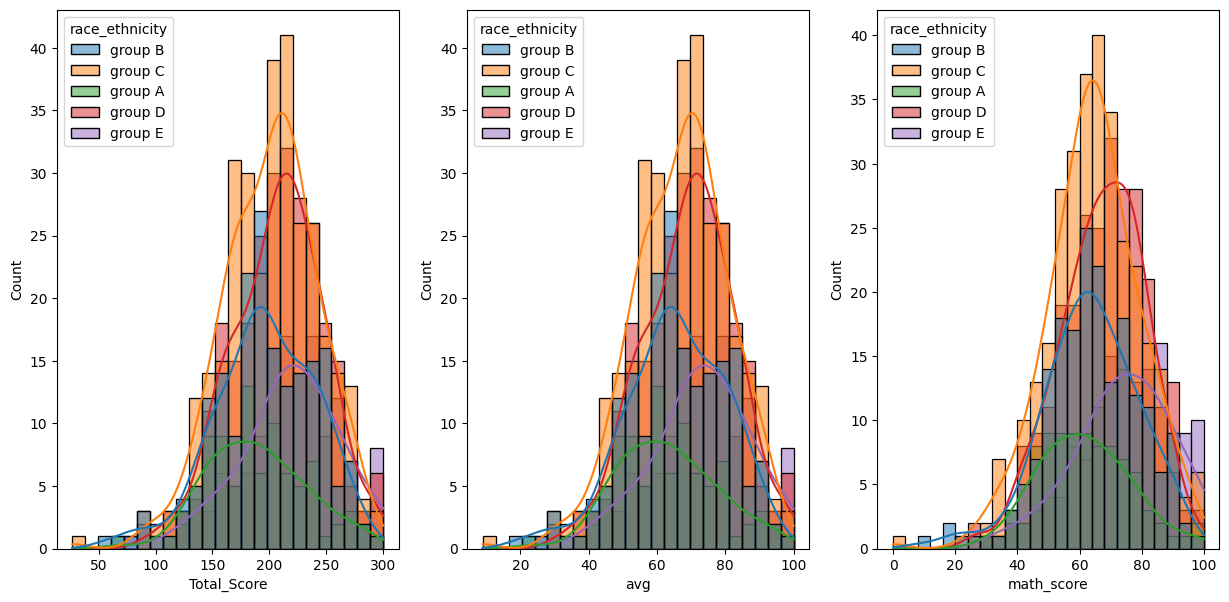

In [5]:
import seaborn as sns
fig,axs = plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(data=data,x='Total_Score',kde=True,hue='race_ethnicity')
plt.subplot(132)
sns.histplot(data=data,x='avg',kde = True, hue = 'race_ethnicity')
plt.subplot(133)
sns.histplot(data=data,x='math_score',kde=True,hue='race_ethnicity')
plt.show()

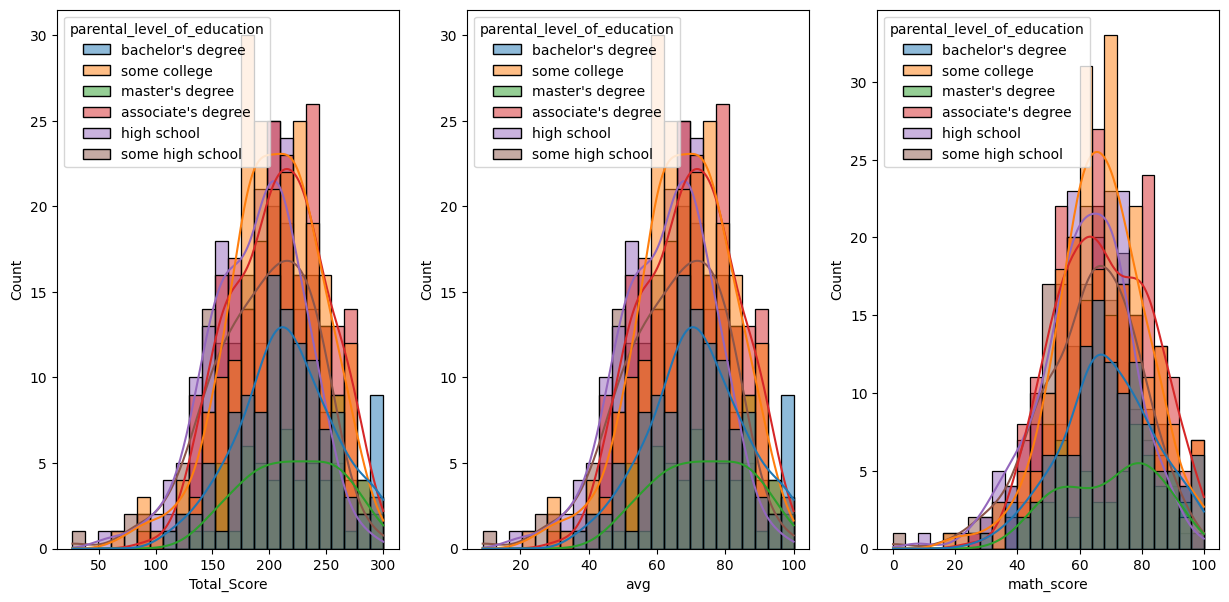

In [6]:
import seaborn as sns
fig,axs = plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(data=data,x='Total_Score',kde=True,hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=data,x='avg',kde = True, hue = 'parental_level_of_education')
plt.subplot(133)
sns.histplot(data=data,x='math_score',kde=True,hue='parental_level_of_education')
plt.show()

In [7]:
data.describe()

,math_score,reading_score,writing_score,Total_Score,avg
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [8]:
y = data['math_score']
data.drop(columns=['math_score'],inplace=True)

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols=[]
num_cols = []

for c in data.columns:
    if data[c].dtype == 'object':
        cat_cols.append(c)
    else :
        num_cols.append(c)

In [10]:
from sklearn.compose import ColumnTransformer

oh_encoder = OneHotEncoder()
scaler = StandardScaler()

preprocessor = ColumnTransformer([('OneHotEncoding',oh_encoder,cat_cols),
                                  ('StandardScaler',scaler,num_cols)])

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.33,random_state=42)

In [12]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)



Train set shape: ((670, 21))


In [15]:
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: ({X_test.shape})")

Train set shape: (670, 21)
Test set shape: ((330, 21))


In [19]:
models ={
    'LinearRegression':linear_model.LinearRegression(),
    'Lasso': linear_model.Lasso(),
    'Ridge': linear_model.Ridge(),
    'XGB': xgb.XGBRegressor(),
    'CatBoost':catb.CatBoostRegressor(verbose=False),
    'SVR': svm.SVR()
}

In [20]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [21]:
model_list=[]
r2=[]

for i in models.keys():
    model = models[i]
    model_list.append(i)
    model.fit(X_train,y_train)
    y_pred_train,y_pred_test = model.predict(X_train),model.predict(X_test)

    r2_train,mae_train,mse_train = r2_score(y_train,y_pred_train),mean_absolute_error(y_train,y_pred_train),mean_squared_error(y_train,y_pred_train)

    r2_test,mae_test,mse_test = r2_score(y_test,y_pred_test),mean_absolute_error(y_test,y_pred_test),mean_squared_error(y_test,y_pred_test)

    r2.append(r2_test)
    
    print("######### METRICS############")
    print("Train Set Results for Model " +i)
    print(f"R2 Score :{r2_train}")
    print(f"MAE:{mae_train}")
    print(f"MSE:{mse_train}")
    print("##########Test#############")
    print(f"R2 Score :{r2_test}")
    print(f"MAE:{mae_test}")
    print(f"MSE:{mse_test}")

######### METRICS############
Train Set Results for Model LinearRegression
R2 Score :1.0
MAE:6.851965098128369e-14
MSE:7.370739528997567e-27
##########Test#############
R2 Score :1.0
MAE:7.316437018523698e-14
MSE:8.554044302102732e-27
######### METRICS############
Train Set Results for Model Lasso
R2 Score :0.9024982883298177
MAE:3.688515349355911
MSE:21.68745190334567
##########Test#############
R2 Score :0.900601463528819
MAE:3.894274575719954
MSE:24.12816777636777
######### METRICS############
Train Set Results for Model Ridge
R2 Score :0.9993411648635792
MAE:0.30575665750815023
MSE:0.14654568713311042
##########Test#############
R2 Score :0.9993423263433382
MAE:0.31842864675806654
MSE:0.15964480859971147
######### METRICS############
Train Set Results for Model XGB
R2 Score :0.9999617693817541
MAE:0.06847544712806816
MSE:0.008503693732553129
##########Test#############
R2 Score :0.9424249762941879
MAE:2.2821071913748074
MSE:13.975858005766085
######### METRICS############
Train Set

In [22]:
pd.DataFrame(list(zip(model_list,r2)),columns=['Model Name', 'R2_score']).sort_values(by='R2_score',ascending=False)

,Model Name,R2_score
0,LinearRegression,1.000000
2,Ridge,0.999342
4,CatBoost,0.967626
3,XGB,0.942425
1,Lasso,0.900601
5,SVR,0.803117
